# Phase 7 — Supplier Risk Scoring

An interpretable, normalized, weighted risk score (0-100) and risk level (Low/Medium/High/Critical) per supplier — deliberately a transparent formula with documented weights, not a black-box model (`src/supplier_risk/scoring.py`).

**Prerequisite:** `make etl` has been run and `DATABASE_URL` points at the populated warehouse.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from src.supplier_risk.features import compute_supplier_features, to_risk_inputs
from src.supplier_risk.scoring import DEFAULT_WEIGHTS, score_suppliers

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


## 1. Raw features

Six metrics per supplier, each traced to where it actually comes from (`src/supplier_risk/features.py`):

| Feature | Source |
|---|---|
| `on_time_rate`, `average_lead_time_days`, `lead_time_std_days` | real `fact_shipments` (DataCo) |
| `defect_rate` | synthetic `fact_returns.reason='Defective item'` proxy (Phase 4) |
| `cost_variability` | synthetic `fact_purchase_orders.unit_cost` (Phase 3) |
| `cancellation_rate` | synthetic `fact_purchase_orders.order_status='Cancelled'` (Phase 3) |

In [2]:
features = compute_supplier_features()
features

,supplier_name,shipment_count,on_time_rate,average_lead_time_days,lead_time_std_days,po_count,cancellation_rate,cost_variability,defect_rate
0,Apparel Supplier,48998,0.428,3.505,1.625,3927,0.050,0.531,0.017
1,Book Shop Supplier,405,0.425,3.390,1.690,16,0.125,0.000,0.022
2,Discs Shop Supplier,2026,0.433,3.562,1.615,81,0.037,0.865,0.010
3,Fan Shop Supplier,66861,0.428,3.495,1.623,4248,0.050,0.831,0.019
4,Fitness Supplier,2479,0.422,3.505,1.625,249,0.048,1.297,0.022
5,Footwear Supplier,14525,0.428,3.492,1.621,1735,0.048,0.560,0.011
6,Golf Supplier,33220,0.427,3.489,1.624,3975,0.047,0.157,0.018
7,Health and Beauty Supplier,362,0.414,3.459,1.577,15,0.000,0.000,0.003
8,Outdoors Supplier,9686,0.421,3.525,1.628,1051,0.053,1.643,0.012
9,Pet Shop Supplier,492,0.386,3.388,1.656,20,0.050,0.000,0.008


## 2. Weighted scoring methodology

Each metric is min-max normalized across the *current* supplier set (0 = best observed, 1 = worst observed) before weighting — this makes every score relative to today's supplier base, not an absolute external scale, and is disclosed here rather than left implicit. `average_lead_time` and `lead_time_variability` (its coefficient of variation) are weighted separately, since a slow-but-consistent supplier and a fast-but-erratic one carry different risks.

In [3]:
weights_table = pd.Series(DEFAULT_WEIGHTS, name='weight').to_frame()
weights_table['pct'] = (weights_table['weight'] * 100).round(0).astype(int).astype(str) + '%'
weights_table

,weight,pct
late_delivery_rate,0.250,25%
average_lead_time,0.100,10%
lead_time_variability,0.150,15%
defect_rate,0.200,20%
cost_volatility,0.150,15%
cancellation_rate,0.150,15%


## 3. Risk scores and levels

In [4]:
risk_inputs = to_risk_inputs(features)
risk_table = score_suppliers(risk_inputs)
risk_table

,supplier_id,risk_score,risk_level
1,Book Shop Supplier,54.490,High
4,Fitness Supplier,52.930,High
9,Pet Shop Supplier,48.278,Medium
8,Outdoors Supplier,47.409,Medium
10,Technology Supplier,42.910,Medium
3,Fan Shop Supplier,42.627,Medium
0,Apparel Supplier,37.800,Medium
6,Golf Supplier,36.073,Medium
5,Footwear Supplier,31.848,Medium
2,Discs Shop Supplier,30.160,Medium


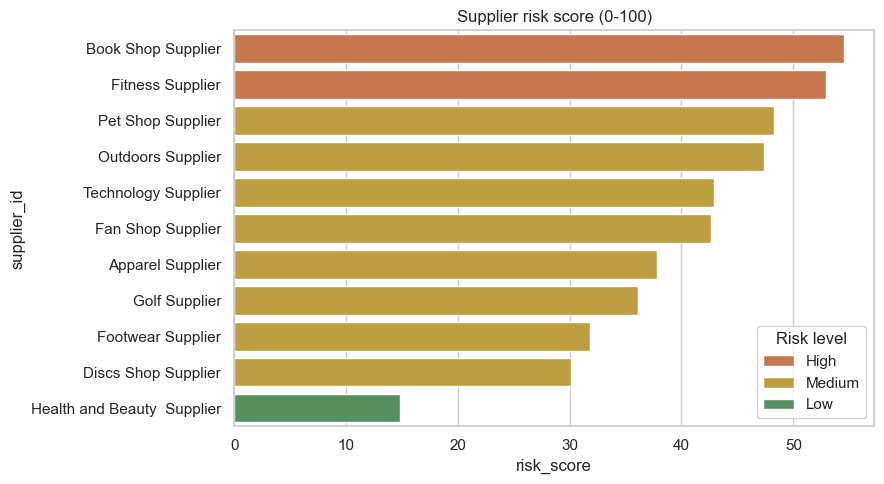

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
palette = {'Low': '#4c9a5b', 'Medium': '#d4a72c', 'High': '#d9713c', 'Critical': '#c0392b'}
sns.barplot(
    data=risk_table, x='risk_score', y='supplier_id', hue='risk_level',
    palette=palette, dodge=False, ax=ax,
)
ax.set_title('Supplier risk score (0-100)')
ax.legend(title='Risk level')
plt.tight_layout()
plt.show()

## 4. Why no ML benchmark

The Phase 7 spec asks for an optional Logistic Regression / Random Forest / XGBoost comparison, **but only if a real historical target exists** — e.g. "this supplier actually caused a stockout/failure" as an independently observed outcome.

That target doesn't exist here. Every one of the six features above is itself either real-but-repurposed (`fact_shipments`, relabeled onto a department-as-supplier model, Phase 2) or explicitly synthetic (`fact_returns`, `fact_purchase_orders`, Phases 3-4). Training a classifier to predict "risk" from these same features would mean fabricating a label from the inputs used to score it — circular by construction, not a real benchmark. Skipping the ML comparison here is the honest choice, not a shortcut (docs/business_requirements.md §7).

## 5. Save results

In [6]:
from pathlib import Path

out_dir = Path('../reports/supplier_risk')
out_dir.mkdir(parents=True, exist_ok=True)
risk_table.to_csv(out_dir / 'supplier_risk_scores.csv', index=False)
(out_dir / 'supplier_risk_scores.md').write_text(
    '# Supplier Risk Scores\n\n' + risk_table.to_markdown(index=False) + '\n',
    encoding='utf-8',
)
print(f'Saved to {out_dir.resolve()}')

Saved to E:\Delliotte\Supply-Chain-Intelligence-Risk-Analytics-Platform\reports\supplier_risk
